In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import pandas as pd
import yfinance as yf

[*********************100%***********************]  4 of 5 completed


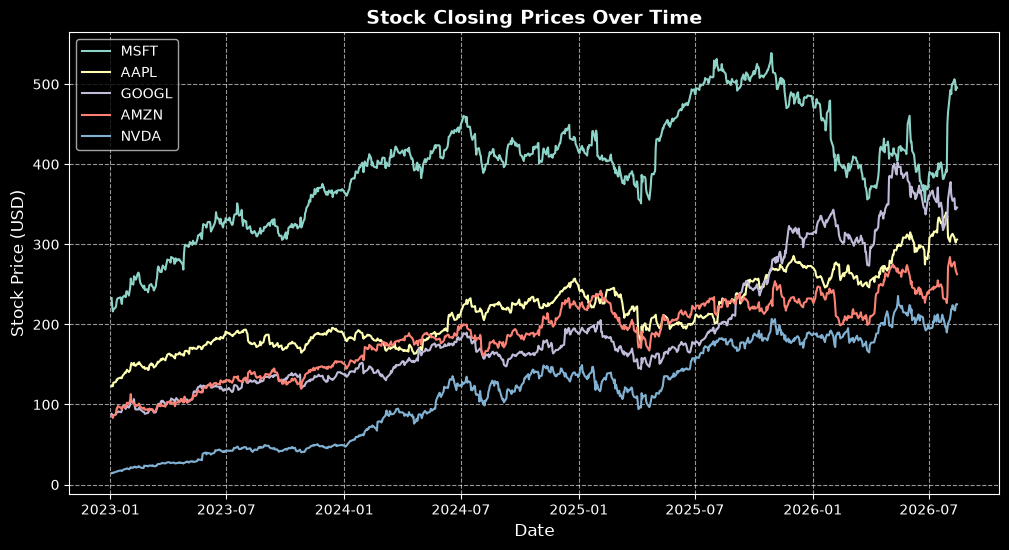

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt

# Define the tech tickers
tickers = ['MSFT', 'AAPL', 'GOOGL', 'AMZN', 'NVDA']

# Fetch the dataset
data = yf.download(tickers, start='2023-01-01', end='2026-08-15')['Close']

# Plot the absolute closing prices
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker, linewidth=1.5)

plt.title('Stock Closing Prices Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()


In [4]:
data.head(10)

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2023-01-03,122.876732,85.820000,88.336693,232.948273,14.283262
2023-01-04,124.144127,85.139999,87.305840,222.758362,14.716301
2023-01-05,122.827614,83.120003,85.442360,216.156296,14.233374
2023-01-06,127.346954,86.080002,86.572342,218.703766,14.826058
2023-01-09,127.867676,87.360001,87.246361,220.833191,15.593351
2023-01-10,128.437469,89.870003,87.642860,222.515289,15.873730
2023-01-11,131.149094,95.089996,90.715599,229.243713,15.965523
2023-01-12,131.070496,95.269997,90.329018,231.907898,16.474392
2023-01-13,132.396820,98.120003,91.310341,232.607971,16.861534


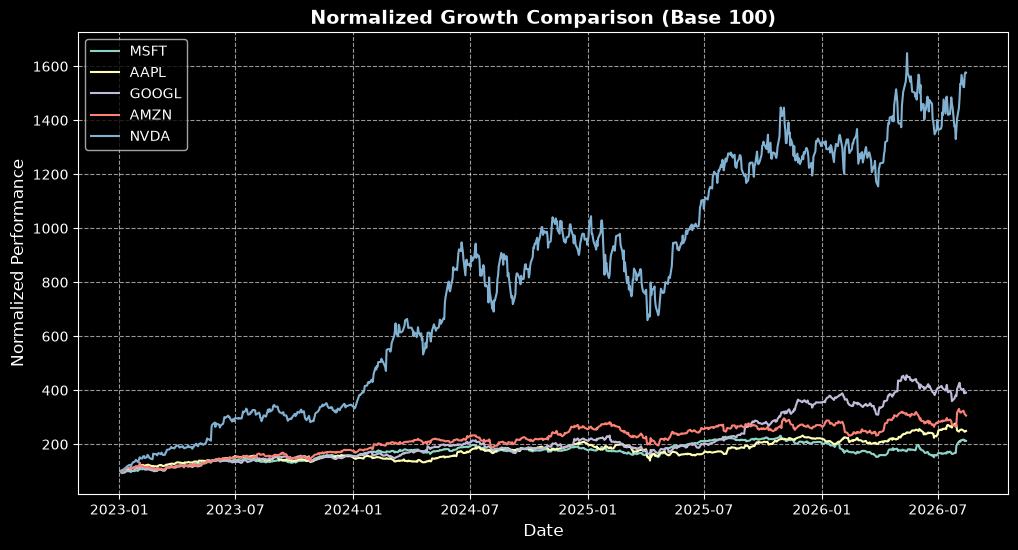

In [5]:
# Normalize prices to start at 100
normalized_data = (data / data.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(normalized_data.index, normalized_data[ticker], label=ticker, linewidth=1.5)

plt.title('Normalized Growth Comparison (Base 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Performance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()


Ticker      AAPL      AMZN     GOOGL      MSFT      NVDA
Ticker                                                  
AAPL    1.000000  0.374470  0.386112  0.377424  0.332007
AMZN    0.374470  1.000000  0.569142  0.545046  0.428561
GOOGL   0.386112  0.569142  1.000000  0.392448  0.374746
MSFT    0.377424  0.545046  0.392448  1.000000  0.458607
NVDA    0.332007  0.428561  0.374746  0.458607  1.000000


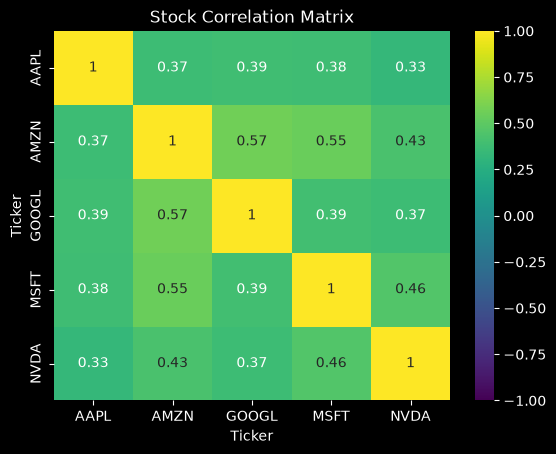

In [6]:
# Calculate daily returns
returns = data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()
print(corr_matrix)

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Stock Correlation Matrix')
plt.show()


[*********************100%***********************]  5 of 5 completed


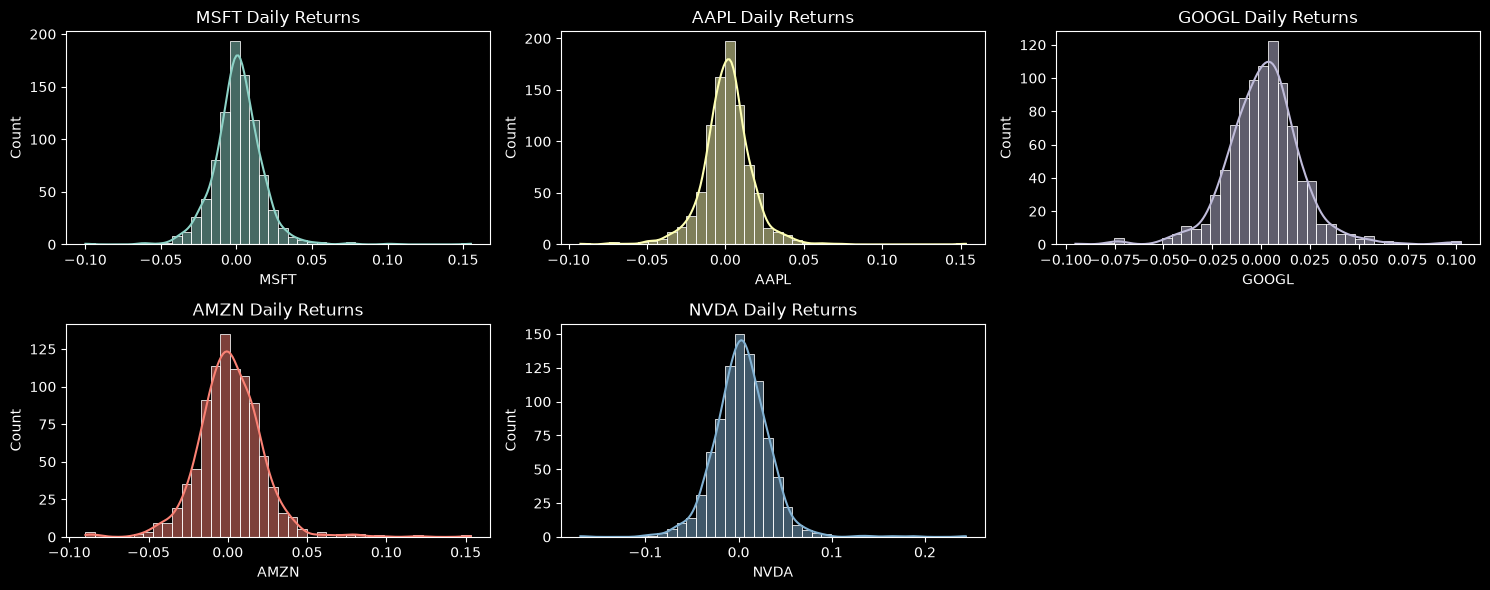

In [7]:
# Explicitly handle multi-index structure from yfinance drops
# 1. FETCH & PROCESS DATA FOR ALL TICKERS
tickers = ['MSFT', 'AAPL', 'GOOGL', 'AMZN', 'NVDA']
print("Downloading historical data...")
raw_data = yf.download(tickers, start="2023-01-01", end="2026-08-15")['Close']
df_close = pd.DataFrame(raw_data)
df_returns = df_close.pct_change().dropna()

# 2. EXPLORATORY DATA ANALYSIS (EDA) - Multi-Ticker Return Distributions
plt.figure(figsize=(15, 6))
for i, ticker in enumerate(tickers):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_returns[ticker], kde=True, bins=40, color=f"C{i}")
    plt.title(f'{ticker} Daily Returns')
plt.tight_layout()
plt.show()

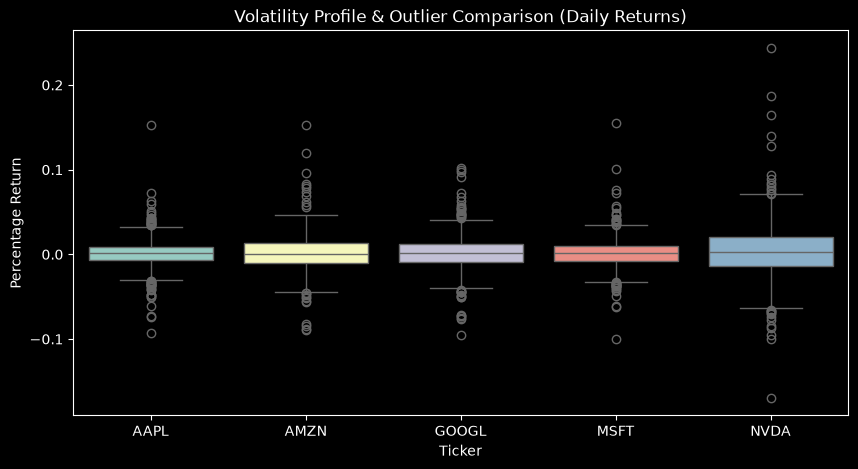

In [8]:
# Multi-Ticker Outlier & Volatility Comparison
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_returns)
plt.title('Volatility Profile & Outlier Comparison (Daily Returns)')
plt.ylabel('Percentage Return')
plt.show()



==================== ANALYZING MSFT ====================
ADF Test p-value (Raw Closing Price): 0.2763
ADF Test p-value (Daily Returns):     0.0000
Conclusion: Returns are Stationary.


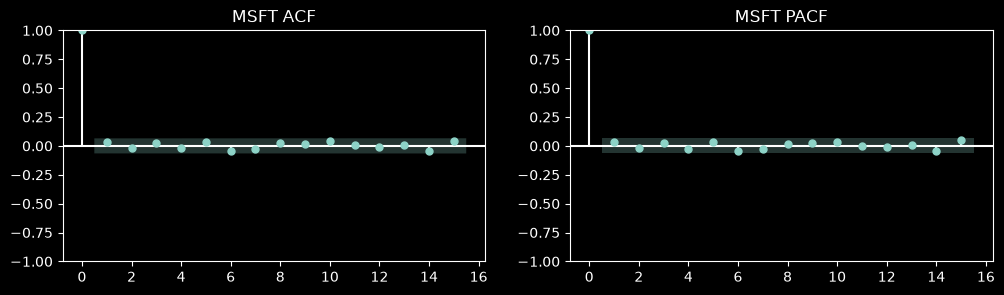

Running TimeSeriesSplit ARIMA(1, 1, 1) validation for MSFT...

==================== ANALYZING AAPL ====================
ADF Test p-value (Raw Closing Price): 0.7168
ADF Test p-value (Daily Returns):     0.0000
Conclusion: Returns are Stationary.


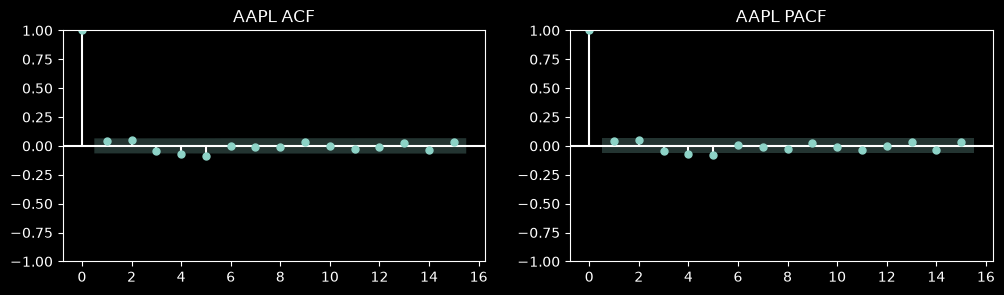

Running TimeSeriesSplit ARIMA(1, 1, 1) validation for AAPL...

==================== ANALYZING GOOGL ====================
ADF Test p-value (Raw Closing Price): 0.9411
ADF Test p-value (Daily Returns):     0.0000
Conclusion: Returns are Stationary.


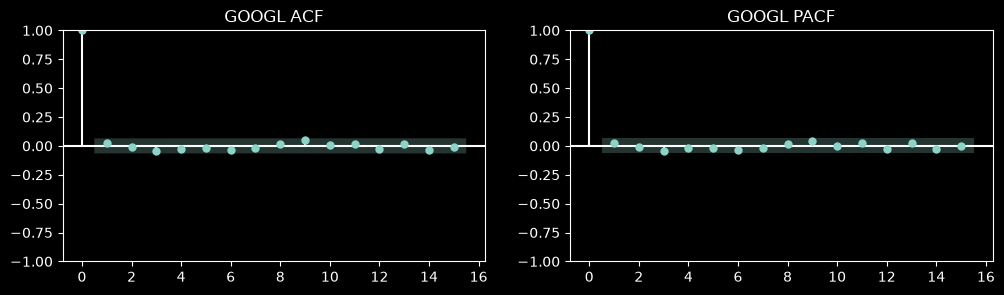

Running TimeSeriesSplit ARIMA(1, 1, 1) validation for GOOGL...


c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



==================== ANALYZING AMZN ====================
ADF Test p-value (Raw Closing Price): 0.5842
ADF Test p-value (Daily Returns):     0.0000
Conclusion: Returns are Stationary.


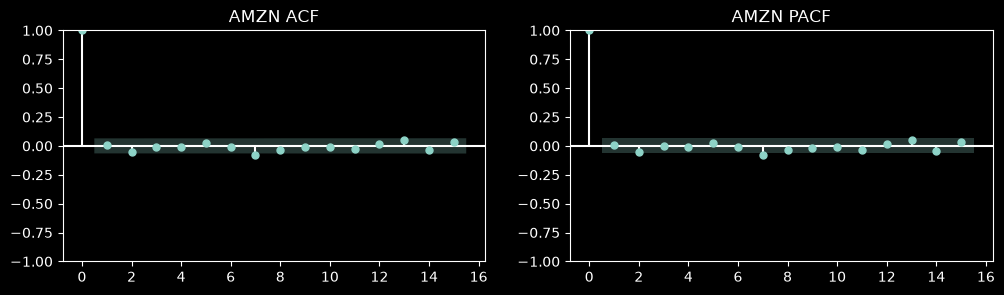

Running TimeSeriesSplit ARIMA(1, 1, 1) validation for AMZN...

==================== ANALYZING NVDA ====================
ADF Test p-value (Raw Closing Price): 0.8713
ADF Test p-value (Daily Returns):     0.0000
Conclusion: Returns are Stationary.


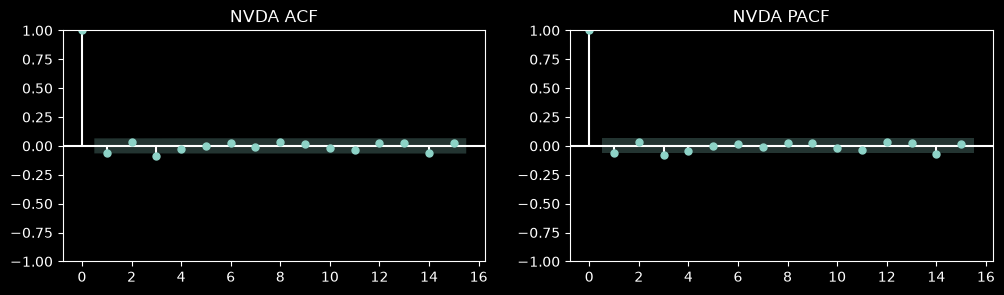

Running TimeSeriesSplit ARIMA(1, 1, 1) validation for NVDA...


c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [9]:
adf_results = {}

for ticker in tickers:
    print(f"\n==================== ANALYZING {ticker} ====================")
    
    # --- Stationarity Check (ADF Test) ---
    raw_adf = adfuller(df_close[ticker])[1]
    ret_adf = adfuller(df_returns[ticker])[1]
    adf_results[ticker] = {'Raw p-val': raw_adf, 'Returns p-val': ret_adf}
    
    print(f"ADF Test p-value (Raw Closing Price): {raw_adf:.4f}")
    print(f"ADF Test p-value (Daily Returns):     {ret_adf:.4f}")
    print("Conclusion: Returns are Stationary." if ret_adf <= 0.05 else "Conclusion: Needs differencing.")
    
    # --- Autocorrelation Profiles (ACF / PACF) ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(df_returns[ticker], lags=15, ax=ax[0], title=f"{ticker} ACF")
    plot_pacf(df_returns[ticker], lags=15, ax=ax[1], method='ywm', title=f"{ticker} PACF")
    plt.show()

    # --- Time Series Cross-Validation & Forecasting ---
    # Using raw prices with d=1 so ARIMA takes care of non-stationarity internally
    X = df_close[ticker].dropna().values
    tscv = TimeSeriesSplit(n_splits=3)
    
    print(f"Running TimeSeriesSplit ARIMA(1, 1, 1) validation for {ticker}...")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        train, test = X[train_idx], X[test_idx]
        
        # Fit model on training fold
        model = ARIMA(train, order=(1, 1, 1))
        model_fit = model.fit()
        
        # Forecast across testing fold horizon
        predictions = model_fit.forecast(steps=len(test))

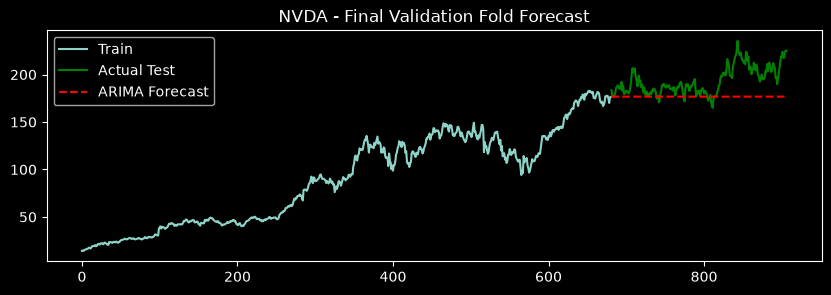


==================== STATIONARITY SUMMARY ====================
       Raw p-val  Returns p-val
MSFT    0.276314   0.000000e+00
AAPL    0.716845   4.753104e-28
GOOGL   0.941081   0.000000e+00
AMZN    0.584240   0.000000e+00
NVDA    0.871295   1.637674e-29


In [10]:
# Plot final fold prediction for this asset
plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(train)), train, label='Train')
plt.plot(np.arange(len(train), len(train)+len(test)), test, label='Actual Test', color='green')
plt.plot(np.arange(len(train), len(train)+len(test)), predictions, label='ARIMA Forecast', color='red', linestyle='--')
plt.title(f"{ticker} - Final Validation Fold Forecast")
plt.legend()
plt.show()
   
# Summary DataFrame of Stationarity
print("\n==================== STATIONARITY SUMMARY ====================")
print(pd.DataFrame(adf_results).T)